# Analise Exploratoria de Dados - Cancer de Utero

Este notebook realiza uma primeira Analise Exploratoria de Dados (EDA) da base em Excel colocada em `data/raw`. A ideia e entender a estrutura da planilha, verificar problemas iniciais de qualidade, observar a distribuicao das variaveis principais e analisar o alvo `label_cid`, que separa os registros por categoria CID.

As quatro primeiras secoes seguem a mesma logica do notebook de referencia:

- carregamento dos dados;
- verificacao inicial da qualidade da base;
- estatisticas descritivas gerais;
- analise inicial do alvo.


## 1. Carregamento dos dados

Nesta etapa carregamos a planilha bruta, verificamos as abas disponiveis e escolhemos automaticamente a primeira aba com dados. Tambem definimos algumas colunas centrais para a analise inicial.


In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [20]:
raw_dir_candidates = [Path("../data/raw"), Path("data/raw")]
raw_dir = next((path for path in raw_dir_candidates if path.exists()), raw_dir_candidates[0])

xlsx_files = sorted(raw_dir.glob("*.xlsx"))
if not xlsx_files:
    raise FileNotFoundError(f"Nenhum arquivo .xlsx encontrado em {raw_dir.resolve()}")

data_path = xlsx_files[0]
excel_file = pd.ExcelFile(data_path)
sheet_shapes = []

for sheet in excel_file.sheet_names:
    preview = pd.read_excel(data_path, sheet_name=sheet, nrows=5)
    sheet_shapes.append({"aba": sheet, "colunas_preview": preview.shape[1], "tem_dados_preview": preview.shape[0] > 0})

sheet_summary = pd.DataFrame(sheet_shapes)
display(sheet_summary)

sheet_name = sheet_summary.loc[sheet_summary["tem_dados_preview"], "aba"].iloc[0]
df = pd.read_excel(data_path, sheet_name=sheet_name)

print(f"Arquivo carregado: {data_path}")
print(f"Aba utilizada: {sheet_name}")
print(f"Shape da base: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas")
print("\nColunas:")
print(df.columns.tolist())


,aba,colunas_preview,tem_dados_preview
0,base_sim_c53_c54_c55_2010_2024_,50,True
1,Planilha1,0,False


Arquivo carregado: ..\data\raw\Base Slim Morte cancer de útero.xlsx
Aba utilizada: base_sim_c53_c54_c55_2010_2024_
Shape da base: 148,785 linhas x 50 colunas

Colunas:
['TIPOBITO', 'DTOBITO', 'NATURAL', 'CODMUNNATU', 'DTNASC', 'idade_obito_anos', 'SEXO', 'RACACOR', 'ESTCIV', 'ESC', 'ESC2010', 'SERIESCFAL', 'OCUP', 'CODMUNRES', 'LOCOCOR', 'CODESTAB', 'ESTABDESCR', 'CODMUNOCOR', 'ASSISTMED', 'EXAME', 'CIRURGIA', 'NECROPSIA', 'LINHAA', 'LINHAB', 'LINHAC', 'LINHAD', 'LINHAII', 'CAUSABAS', 'causabas_categoria', 'causabas_subcategoria', 'CB_PRE', 'COMUNSVOIM', 'CAUSABAS_O', 'CAUSAMAT', 'ESCFALAGR1', 'NUDIASOBCO', 'NUDIASINF', 'ALTCAUSA', 'res_AMAZONIA', 'res_FRONTEIRA', 'res_CAPITAL', 'ocor_AMAZONIA', 'ocor_FRONTEIRA', 'ocor_CAPITAL', 'ocor_SIGLA_UF', 'ocor_CODIGO_UF', 'res_SIGLA_UF', 'ocor_REGIAO', 'res_REGIAO', 'label_cid']


In [21]:
target_col = "label_cid"
age_col = "idade_obito_anos"
death_date_col = "DTOBITO"
birth_date_col = "DTNASC"

region_cols = [col for col in ["res_REGIAO", "ocor_REGIAO"] if col in df.columns]
uf_cols = [col for col in ["res_SIGLA_UF", "ocor_SIGLA_UF"] if col in df.columns]
cause_cols = [
    col
    for col in ["CAUSABAS", "causabas_categoria", "causabas_subcategoria", "CB_PRE", target_col]
    if col in df.columns
]
selected_context_cols = [col for col in [age_col, death_date_col, birth_date_col, target_col] if col in df.columns]

display(df.head())
display(Markdown("### Colunas centrais identificadas"))
display(pd.DataFrame({
    "grupo": ["alvo", "idade", "datas", "regiao", "uf", "causas"],
    "colunas": [
        [target_col] if target_col in df.columns else [],
        [age_col] if age_col in df.columns else [],
        [col for col in [death_date_col, birth_date_col] if col in df.columns],
        region_cols,
        uf_cols,
        cause_cols,
    ],
}))


,TIPOBITO,DTOBITO,NATURAL,CODMUNNATU,DTNASC,idade_obito_anos,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,ESTABDESCR,CODMUNOCOR,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CAUSABAS,causabas_categoria,causabas_subcategoria,CB_PRE,COMUNSVOIM,CAUSABAS_O,CAUSAMAT,ESCFALAGR1,NUDIASOBCO,NUDIASINF,ALTCAUSA,res_AMAZONIA,res_FRONTEIRA,res_CAPITAL,ocor_AMAZONIA,ocor_FRONTEIRA,ocor_CAPITAL,ocor_SIGLA_UF,ocor_CODIGO_UF,res_SIGLA_UF,ocor_REGIAO,res_REGIAO,label_cid
0,2,24042010,NaN,NaN,"27,041,977.0000",32.0000,2,9,1,9,NaN,NaN,"999,992.0000",120040,3,NaN,NaN,120040,9,1,2,2,*C55X,*B199,NaN,NaN,NaN,C55,C55 Neopl malig do utero porcao NE,C55 Neopl malig do utero porcao NE,B182,NaN,R98,NaN,NaN,NaN,NaN,NaN,S,S,S,S,S,S,AC,12,AC,Norte,Norte,C55
1,2,3122010,812.0000,NaN,"28,081,961.0000",49.0000,2,1,1,1,NaN,NaN,"612,005.0000",120010,1,"2,001,500.0000",NaN,120010,9,9,9,9,*C782,*C549,NaN,NaN,NaN,C549,C54 Neopl malig do corpo do utero,C54.9 Corpo do utero NE,C549,NaN,C549,NaN,NaN,NaN,NaN,NaN,S,S,N,S,S,N,AC,12,AC,Norte,Norte,C54
2,2,22072010,812.0000,NaN,"20,011,939.0000",71.0000,2,4,9,9,NaN,NaN,"999,993.0000",120060,3,NaN,NaN,120060,9,2,2,2,*C539,*I469,NaN,NaN,NaN,C539,C53 Neopl malig do colo do utero,C53.9 Colo do utero NE,C539,NaN,C539,NaN,NaN,NaN,NaN,NaN,S,S,N,S,S,N,AC,12,AC,Norte,Norte,C53
3,2,27082010,812.0000,NaN,"20,061,932.0000",78.0000,2,4,3,1,NaN,NaN,"999,993.0000",120040,1,"2,001,586.0000",NaN,120040,9,1,2,2,*J189,*E43X,*E86X,*C539,NaN,C539,C53 Neopl malig do colo do utero,C53.9 Colo do utero NE,C539,NaN,C539,NaN,NaN,NaN,NaN,NaN,S,S,S,S,S,S,AC,12,AC,Norte,Norte,C53
4,2,13092010,813.0000,NaN,"19,111,952.0000",57.0000,2,4,3,9,NaN,NaN,"999,992.0000",120040,1,"2,001,586.0000",NaN,120040,9,2,2,2,*C55X,*N179,NaN,NaN,NaN,C55,C55 Neopl malig do utero porcao NE,C55 Neopl malig do utero porcao NE,C55,NaN,C55,NaN,NaN,NaN,NaN,NaN,S,S,S,S,S,S,AC,12,AC,Norte,Norte,C55


### Colunas centrais identificadas

,grupo,colunas
0,alvo,[label_cid]
1,idade,[idade_obito_anos]
2,datas,"[DTOBITO, DTNASC]"
3,regiao,"[res_REGIAO, ocor_REGIAO]"
4,uf,"[res_SIGLA_UF, ocor_SIGLA_UF]"
5,causas,"[CAUSABAS, causabas_categoria, causabas_subcat..."


## 2. Verificacao inicial da qualidade da base

Antes de discutir distribuicoes, e importante verificar se a base apresenta problemas estruturais. Nesta secao analisamos:

- valores nulos;
- tipos de dados;
- duplicatas;
- valores infinitos em colunas numericas;
- colunas constantes ou quase constantes;
- inconsistencias simples em idade e datas;
- codigos de ausencia ou ignorado em variaveis categoricas/codificadas.

Essas verificacoes ajudam a separar problemas reais de qualidade de dados de caracteristicas esperadas em bases administrativas de mortalidade.


In [22]:
def build_count_percent_table(series: pd.Series, total_rows: int, count_name: str = "count") -> pd.DataFrame:
    summary = pd.DataFrame({count_name: series})
    summary["percent"] = 100 * summary[count_name] / total_rows
    return summary


def display_section(title: str) -> None:
    display(Markdown(f"### {title}"))


def parse_yyyymmdd(series: pd.Series) -> pd.Series:
    values = series.copy()
    values = values.where(values.notna(), np.nan)
    values = values.astype("Int64").astype(str).replace("<NA>", np.nan)
    return pd.to_datetime(values, format="%Y%m%d", errors="coerce")


In [23]:
n_rows = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

null_summary = build_count_percent_table(df.isna().sum(), n_rows, count_name="null_count")
dtype_summary = pd.DataFrame({"dtype": df.dtypes.astype(str), "unique_values": df.nunique(dropna=True)})
inf_summary = build_count_percent_table(
    pd.Series(np.isinf(df[numeric_cols]).sum(), index=numeric_cols) if numeric_cols else pd.Series(dtype=int),
    n_rows,
    count_name="inf_count",
)

duplicate_summary = pd.DataFrame({"count": [int(df.duplicated().sum())]}, index=["duplicated_rows"])
duplicate_summary["percent"] = 100 * duplicate_summary["count"] / n_rows

constant_cols = dtype_summary.query("unique_values <= 1").copy()
near_constant_cols = dtype_summary.query("unique_values > 1 and unique_values <= 3").copy()

display_section("Resumo geral")
display(pd.DataFrame({
    "indicador": ["linhas", "colunas", "colunas_numericas", "colunas_categoricas"],
    "valor": [n_rows, df.shape[1], len(numeric_cols), len(categorical_cols)],
}))

display_section("Valores nulos por coluna")
display(null_summary.sort_values(["null_count", "percent"], ascending=False))

display_section("Tipos de dados e cardinalidade")
display(dtype_summary.sort_values("unique_values", ascending=False))

display_section("Valores infinitos por coluna numerica")
display(inf_summary.sort_values("inf_count", ascending=False))

display_section("Duplicatas")
display(duplicate_summary)

display_section("Colunas constantes")
display(constant_cols if not constant_cols.empty else pd.DataFrame({"mensagem": ["Nenhuma coluna constante encontrada."]}))

display_section("Colunas com ate 3 valores distintos")
display(near_constant_cols)


### Resumo geral

,indicador,valor
0,linhas,148785
1,colunas,50
2,colunas_numericas,28
3,colunas_categoricas,22


### Valores nulos por coluna

,null_count,percent
CAUSAMAT,148785,100.0000
NUDIASINF,148785,100.0000
ALTCAUSA,148784,99.9993
ESTABDESCR,148782,99.9980
COMUNSVOIM,143646,96.5460
CB_PRE,140719,94.5788
SERIESCFAL,122003,81.9995
NUDIASOBCO,120157,80.7588
LINHAD,119432,80.2715
LINHAII,109716,73.7413


### Tipos de dados e cardinalidade

...

,count,percent
duplicated_rows,3,0.0020


### Colunas constantes

,dtype,unique_values
TIPOBITO,int64,1
SEXO,int64,1
CAUSAMAT,float64,0
NUDIASINF,float64,0
ALTCAUSA,float64,1


### Colunas com ate 3 valores distintos

,dtype,unique_values
ESTABDESCR,str,3
ASSISTMED,int64,3
EXAME,int64,3
CIRURGIA,int64,3
NECROPSIA,int64,3
causabas_categoria,str,3
res_AMAZONIA,str,2
res_FRONTEIRA,str,2
res_CAPITAL,str,2
ocor_AMAZONIA,str,2


### Verificacoes de idade e datas

A idade ao obito e as datas sao variaveis importantes para entender a consistencia temporal da base. Aqui convertemos datas no padrao `AAAAMMDD`, quando possivel, apenas em memoria.


In [24]:
quality_checks = {}

if age_col in df.columns:
    quality_checks["idade_nula"] = df[age_col].isna().sum()
    quality_checks["idade_negativa"] = (df[age_col] < 0).sum()
    quality_checks["idade_maior_120"] = (df[age_col] > 120).sum()

date_quality = []
date_columns = [col for col in [death_date_col, birth_date_col] if col in df.columns]

for col in date_columns:
    parsed = parse_yyyymmdd(df[col])
    date_quality.append({
        "coluna": col,
        "datas_validas": parsed.notna().sum(),
        "datas_invalidas_ou_nulas": parsed.isna().sum(),
        "min": parsed.min(),
        "max": parsed.max(),
    })

if all(col in df.columns for col in [death_date_col, birth_date_col]):
    death_dates = parse_yyyymmdd(df[death_date_col])
    birth_dates = parse_yyyymmdd(df[birth_date_col])
    quality_checks["nascimento_depois_do_obito"] = (birth_dates > death_dates).sum()

display_section("Checagens simples de idade e consistencia temporal")
display(build_count_percent_table(pd.Series(quality_checks), n_rows) if quality_checks else pd.DataFrame())

display_section("Resumo de conversao das datas")
display(pd.DataFrame(date_quality))


### Checagens simples de idade e consistencia temporal

,count,percent
idade_nula,11,0.0074
idade_negativa,0,0.0000
idade_maior_120,0,0.0000
nascimento_depois_do_obito,315,0.2117


### Resumo de conversao das datas

,coluna,datas_validas,datas_invalidas_ou_nulas,min,max
0,DTOBITO,38399,110386,1012-01-01,9122-02-04
1,DTNASC,2400,146385,1011-09-17,9121-09-30


### Codigos de ausencia, ignorado ou nao informado

Bases do SIM e bases administrativas frequentemente usam codigos como `9`, `99`, `999` ou textos como `IGNORADO`. Esta tabela nao remove nada; ela apenas sinaliza onde pode haver categorias que precisam de tratamento no pre-processamento.


In [25]:
missing_like_tokens = {"", " ", "9", "99", "999", "9999", "IGN", "IGNORADO", "NAO INFORMADO"}
missing_like_summary = []

for col in df.columns:
    values_as_text = df[col].astype("string").str.strip().str.upper()
    count = values_as_text.isin(missing_like_tokens).sum()
    if count > 0:
        missing_like_summary.append({
            "coluna": col,
            "missing_like_count": int(count),
            "percent": 100 * count / n_rows,
        })

missing_like_summary = pd.DataFrame(missing_like_summary)
display(missing_like_summary.sort_values("missing_like_count", ascending=False) if not missing_like_summary.empty else pd.DataFrame({"mensagem": ["Nenhum codigo desse tipo foi encontrado."]}))


,coluna,missing_like_count,percent
6,CIRURGIA,140890,94.6937
5,EXAME,140457,94.4027
4,ASSISTMED,50074,33.6553
7,NECROPSIA,43328,29.1212
2,ESC,23412,15.7355
1,ESTCIV,15337,10.3082
0,RACACOR,4689,3.1515
3,LOCOCOR,46,0.0309


### Valores extremos em variaveis continuas

A regra do IQR e usada aqui apenas para sinalizar observacoes atipicas. Como varias colunas numericas sao codigos categoricos, aplicamos essa leitura inicialmente em variaveis com interpretacao continua, como idade e intervalos em dias.


In [26]:
continuous_cols = [col for col in [age_col, "NUDIASOBCO", "NUDIASINF"] if col in df.columns]

if continuous_cols:
    q1 = df[continuous_cols].quantile(0.25)
    q3 = df[continuous_cols].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    extreme_summary = pd.DataFrame(index=continuous_cols)
    extreme_summary["lower_fence"] = lower_fence
    extreme_summary["upper_fence"] = upper_fence
    extreme_summary["below_lower_fence"] = [int((df[col] < lower_fence[col]).sum()) for col in continuous_cols]
    extreme_summary["above_upper_fence"] = [int((df[col] > upper_fence[col]).sum()) for col in continuous_cols]
    extreme_summary["total_extreme"] = extreme_summary["below_lower_fence"] + extreme_summary["above_upper_fence"]
    extreme_summary["percent_extreme"] = 100 * extreme_summary["total_extreme"] / n_rows

    display(extreme_summary.sort_values("percent_extreme", ascending=False))
else:
    display(pd.DataFrame({"mensagem": ["Nenhuma coluna continua pre-definida foi encontrada."]}))


,lower_fence,upper_fence,below_lower_fence,above_upper_fence,total_extreme,percent_extreme
NUDIASOBCO,-89.0000,215.0000,0,1923,1923,1.2925
idade_obito_anos,12.0000,108.0000,1,6,7,0.0047
NUDIASINF,NaN,NaN,0,0,0,0.0000


### Leituras iniciais da qualidade da base

Depois de executar as tabelas acima, observe principalmente:

- quais colunas tem muitos valores nulos;
- quais colunas sao codigos categoricos, mesmo aparecendo como numericas;
- se `idade_obito_anos` tem valores fora de uma faixa plausivel;
- se as datas foram convertidas corretamente;
- se existem colunas constantes que nao devem entrar no modelo;
- se codigos como `9`, `99` e `IGNORADO` devem virar uma categoria explicita ou valor ausente no pre-processamento.

Essa leitura e especialmente importante antes de aplicar rede neural, porque a rede vai exigir codificacao adequada das variaveis categoricas e padronizacao das variaveis numericas continuas.


## 3. Estatisticas descritivas gerais

Nesta etapa analisamos a escala das variaveis, a cardinalidade das colunas categoricas e algumas distribuicoes iniciais. O objetivo e identificar o que precisara de tratamento antes do algoritmo genetico e da rede neural.


### Visao tabular geral


In [27]:
display(df[selected_context_cols + region_cols + uf_cols + cause_cols].head())

describe_all = df.describe(include="all").T

feature_groups = {
    "Obito, datas e origem": ["TIPOBITO", "DTOBITO", "DTNASC", age_col, "NATURAL", "CODMUNNATU"],
    "Perfil sociodemografico": ["SEXO", "RACACOR", "ESTCIV", "ESC", "ESC2010", "SERIESCFAL", "OCUP", "ESCFALAGR1"],
    "Residencia": ["CODMUNRES", "res_AMAZONIA", "res_FRONTEIRA", "res_CAPITAL", "res_SIGLA_UF", "res_REGIAO"],
    "Ocorrencia": ["LOCOCOR", "CODESTAB", "ESTABDESCR", "CODMUNOCOR", "ocor_AMAZONIA", "ocor_FRONTEIRA", "ocor_CAPITAL", "ocor_SIGLA_UF", "ocor_CODIGO_UF", "ocor_REGIAO"],
    "Assistencia e investigacao": ["ASSISTMED", "EXAME", "CIRURGIA", "NECROPSIA", "COMUNSVOIM", "NUDIASOBCO", "NUDIASINF", "ALTCAUSA"],
    "Causas e linhas da declaracao": ["LINHAA", "LINHAB", "LINHAC", "LINHAD", "LINHAII", "CAUSABAS", "CAUSABAS_O", "CAUSAMAT"],
    "Categorias CID": ["causabas_categoria", "causabas_subcategoria", "CB_PRE", target_col],
}

shown_cols = []
group_size = 8

for group_name, group_cols in feature_groups.items():
    available_cols = [col for col in group_cols if col in df.columns]
    shown_cols.extend(available_cols)

    for start in range(0, len(available_cols), group_size):
        block_cols = available_cols[start:start + group_size]
        suffix = f" - parte {start // group_size + 1}" if len(available_cols) > group_size else ""
        display_section(f"Describe - {group_name}{suffix}")
        display(describe_all.loc[block_cols])

remaining_cols = [col for col in df.columns if col not in shown_cols]

for start in range(0, len(remaining_cols), group_size):
    block_cols = remaining_cols[start:start + group_size]
    display_section(f"Describe - Outras features - parte {start // group_size + 1}")
    display(describe_all.loc[block_cols])


,idade_obito_anos,DTOBITO,DTNASC,label_cid,res_REGIAO,ocor_REGIAO,res_SIGLA_UF,ocor_SIGLA_UF,CAUSABAS,causabas_categoria,causabas_subcategoria,CB_PRE,label_cid
0,32.0000,24042010,"27,041,977.0000",C55,Norte,Norte,AC,AC,C55,C55 Neopl malig do utero porcao NE,C55 Neopl malig do utero porcao NE,B182,C55
1,49.0000,3122010,"28,081,961.0000",C54,Norte,Norte,AC,AC,C549,C54 Neopl malig do corpo do utero,C54.9 Corpo do utero NE,C549,C54
2,71.0000,22072010,"20,011,939.0000",C53,Norte,Norte,AC,AC,C539,C53 Neopl malig do colo do utero,C53.9 Colo do utero NE,C539,C53
3,78.0000,27082010,"20,061,932.0000",C53,Norte,Norte,AC,AC,C539,C53 Neopl malig do colo do utero,C53.9 Colo do utero NE,C539,C53
4,57.0000,13092010,"19,111,952.0000",C55,Norte,Norte,AC,AC,C55,C55 Neopl malig do utero porcao NE,C55 Neopl malig do utero porcao NE,C55,C55


### Describe - Obito, datas e origem

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TIPOBITO,"148,785.0000",NaN,NaN,NaN,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,2.0000
DTOBITO,"148,785.0000",NaN,NaN,NaN,"15,807,439.3445","8,794,495.4531","1,012,010.0000","8,082,023.0000","16,032,022.0000","23,102,024.0000","31,122,024.0000"
DTNASC,"148,729.0000",NaN,NaN,NaN,"15,402,726.3766","8,723,052.3898","1,011,917.0000","8,051,970.0000","15,081,943.0000","23,041,967.0000","31,121,998.0000"
idade_obito_anos,"148,774.0000",NaN,NaN,NaN,60.0026,16.0023,11.0000,48.0000,60.0000,72.0000,114.0000
NATURAL,"118,074.0000",NaN,NaN,NaN,825.1163,62.6627,4.0000,825.0000,831.0000,835.0000,999.0000
CODMUNNATU,"107,969.0000",NaN,NaN,NaN,"308,679.3790","90,915.0921","110,000.0000","250,400.0000","312,270.0000","354,910.0000","539,924.0000"


### Describe - Perfil sociodemografico

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SEXO,"148,785.0000",NaN,NaN,NaN,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,2.0000
RACACOR,"148,785.0000",NaN,NaN,NaN,2.6015,1.8270,1.0000,1.0000,2.0000,4.0000,9.0000
ESTCIV,"148,785.0000",NaN,NaN,NaN,2.7650,2.3006,1.0000,1.0000,2.0000,3.0000,9.0000
ESC,"148,785.0000",NaN,NaN,NaN,3.7618,2.5178,1.0000,2.0000,3.0000,4.0000,9.0000
ESC2010,"124,339.0000",NaN,NaN,NaN,2.4834,2.5397,0.0000,1.0000,2.0000,3.0000,9.0000
SERIESCFAL,"26,782.0000",NaN,NaN,NaN,4.4419,1.9659,1.0000,3.0000,4.0000,5.0000,8.0000
OCUP,"130,484.0000",NaN,NaN,NaN,"803,207.7621","266,745.2483","10,210.0000","524,205.0000","999,992.0000","999,992.0000","999,995.0000"
ESCFALAGR1,"108,828.0000",NaN,NaN,NaN,7.1661,4.2669,0.0000,2.0000,9.0000,11.0000,12.0000


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ASSISTMED,"148,785.0000",NaN,NaN,NaN,3.7187,3.7649,1.0000,1.0000,1.0000,9.0000,9.0000
EXAME,"148,785.0000",NaN,NaN,NaN,8.5633,1.7958,1.0000,9.0000,9.0000,9.0000,9.0000
CIRURGIA,"148,785.0000",NaN,NaN,NaN,8.6155,1.6272,1.0000,9.0000,9.0000,9.0000,9.0000
NECROPSIA,"148,785.0000",NaN,NaN,NaN,4.0196,3.1953,1.0000,2.0000,2.0000,9.0000,9.0000
COMUNSVOIM,"5,139.0000",NaN,NaN,NaN,"319,019.2586","101,597.7699","110,002.0000","230,440.0000","310,620.0000","355,030.0000","530,010.0000"
NUDIASOBCO,"28,628.0000",NaN,NaN,NaN,79.1271,87.8135,0.0000,25.0000,54.0000,101.0000,794.0000
NUDIASINF,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALTCAUSA,1.0000,NaN,NaN,NaN,2.0000,NaN,2.0000,2.0000,2.0000,2.0000,2.0000


### Describe - Causas e linhas da declaracao

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LINHAA,144150,1505,*C539,22351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LINHAB,108418,2290,*C539,19980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LINHAC,70970,1895,*C539,22857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LINHAD,29353,1059,*C539,13277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LINHAII,39069,7364,*C539,3535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAUSABAS,148785,11,C539,85903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAUSABAS_O,148701,447,C539,83080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAUSAMAT,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Describe - Categorias CID

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
causabas_categoria,148785,3,C53 Neopl malig do colo do utero,92287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causabas_subcategoria,144943,11,C53.9 Colo do utero NE,85903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CB_PRE,8066,37,C539,4777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_cid,148785,3,C53,92287,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Escalas das variaveis numericas

A tabela abaixo ajuda a distinguir variaveis realmente continuas de codigos numericos. Em redes neurais, variaveis continuas costumam precisar de padronizacao, enquanto codigos categoricos precisam de codificacao apropriada.


In [28]:
numeric_scale_summary = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numeric_scale_summary["iqr"] = numeric_scale_summary["75%"] - numeric_scale_summary["25%"]
numeric_scale_summary["missing_percent"] = 100 * df[numeric_cols].isna().sum() / n_rows
display(numeric_scale_summary.sort_values("missing_percent", ascending=False))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,missing_percent
CAUSAMAT,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000
NUDIASINF,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000
ALTCAUSA,1.0000,2.0000,NaN,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,0.0000,99.9993
COMUNSVOIM,"5,139.0000","319,019.2586","101,597.7699","110,002.0000","150,140.0000","210,381.5000","230,440.0000","310,620.0000","355,030.0000","520,870.0000","530,010.0000","530,010.0000","124,590.0000",96.5460
SERIESCFAL,"26,782.0000",4.4419,1.9659,1.0000,1.0000,2.0000,3.0000,4.0000,5.0000,8.0000,8.0000,8.0000,2.0000,81.9995
NUDIASOBCO,"28,628.0000",79.1271,87.8135,0.0000,0.0000,3.0000,25.0000,54.0000,101.0000,253.0000,456.0000,794.0000,76.0000,80.7588
CODMUNNATU,"107,969.0000","308,679.3790","90,915.0921","110,000.0000","130,068.0000","150,140.0000","250,400.0000","312,270.0000","354,910.0000","432,240.0000","521,570.0000","539,924.0000","104,510.0000",27.4329
ESCFALAGR1,"108,828.0000",7.1661,4.2669,0.0000,0.0000,0.0000,2.0000,9.0000,11.0000,12.0000,12.0000,12.0000,9.0000,26.8555
NATURAL,"118,074.0000",825.1163,62.6627,4.0000,800.0000,814.0000,825.0000,831.0000,835.0000,843.0000,852.0000,999.0000,10.0000,20.6412
ESC2010,"124,339.0000",2.4834,2.5397,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,9.0000,9.0000,9.0000,2.0000,16.4304


### Cardinalidade e categorias mais frequentes

Aqui vemos quantos valores distintos existem em cada variavel categorica e quais categorias aparecem com maior frequencia nas principais colunas textuais.


In [29]:
categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(dropna=True),
    "missing_percent": 100 * df[categorical_cols].isna().sum() / n_rows,
}).sort_values("unique_values", ascending=False)

display(categorical_summary)

top_category_cols = [col for col in [target_col, "CAUSABAS", "causabas_categoria", "causabas_subcategoria", "res_REGIAO", "ocor_REGIAO", "res_SIGLA_UF", "ocor_SIGLA_UF"] if col in df.columns]

for col in top_category_cols:
    display_section(f"Top categorias - {col}")
    top_values = df[col].value_counts(dropna=False).head(15).rename_axis(col).reset_index(name="frequencia")
    top_values["percent"] = 100 * top_values["frequencia"] / n_rows
    display(top_values)


,unique_values,missing_percent
LINHAII,7364,73.7413
LINHAB,2290,27.1311
LINHAC,1895,52.3003
LINHAA,1505,3.1152
LINHAD,1059,80.2715
CAUSABAS_O,447,0.0565
CB_PRE,37,94.5788
res_SIGLA_UF,27,0.0000
ocor_SIGLA_UF,27,0.0000
causabas_subcategoria,11,2.5822


### Top categorias - label_cid

,label_cid,frequencia,percent
0,C53,92287,62.0271
1,C55,30345,20.3952
2,C54,26153,17.5777


### Top categorias - CAUSABAS

,CAUSABAS,frequencia,percent
0,C539,85903,57.7363
1,C55,30345,20.3952
2,C541,21279,14.3018
3,C538,5465,3.6731
4,C549,3931,2.6421
5,C530,676,0.4543
6,C548,630,0.4234
7,C531,243,0.1633
8,C540,127,0.0854
9,C542,115,0.0773


...

,ocor_REGIAO,frequencia,percent
0,Sudeste,59254,39.8253
1,Nordeste,41770,28.0741
2,Sul,22412,15.0633
3,Norte,14731,9.9009
4,Centro-Oeste,10618,7.1365


### Top categorias - res_SIGLA_UF

,res_SIGLA_UF,frequencia,percent
0,SP,28062,18.8608
1,RJ,15819,10.6321
2,MG,11970,8.0452
3,BA,9433,6.3400
4,RS,9328,6.2694
5,PR,8298,5.5772
6,PE,7924,5.3258
7,CE,6422,4.3163
8,PA,6422,4.3163
9,MA,6042,4.0609


### Top categorias - ocor_SIGLA_UF

,ocor_SIGLA_UF,frequencia,percent
0,SP,28643,19.2513
1,RJ,15766,10.5965
2,MG,11790,7.9242
3,RS,9326,6.2681
4,BA,9233,6.2056
5,PR,8352,5.6135
6,PE,8004,5.3796
7,CE,6430,4.3217
8,PA,6306,4.2383
9,MA,5810,3.9050


### Distribuicoes iniciais


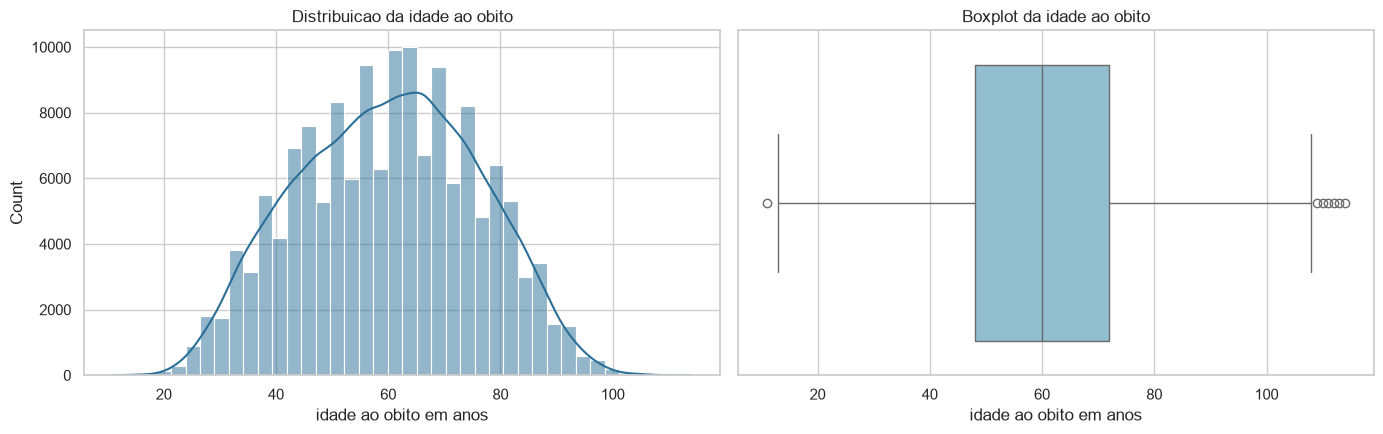

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

if age_col in df.columns:
    sns.histplot(df[age_col].dropna(), bins=40, kde=True, ax=axes[0], color="#2a6f97")
    axes[0].set_title("Distribuicao da idade ao obito")
    axes[0].set_xlabel("idade ao obito em anos")

    sns.boxplot(x=df[age_col], ax=axes[1], color="#89c2d9")
    axes[1].set_title("Boxplot da idade ao obito")
    axes[1].set_xlabel("idade ao obito em anos")
else:
    axes[0].text(0.5, 0.5, "Coluna de idade nao encontrada", ha="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()


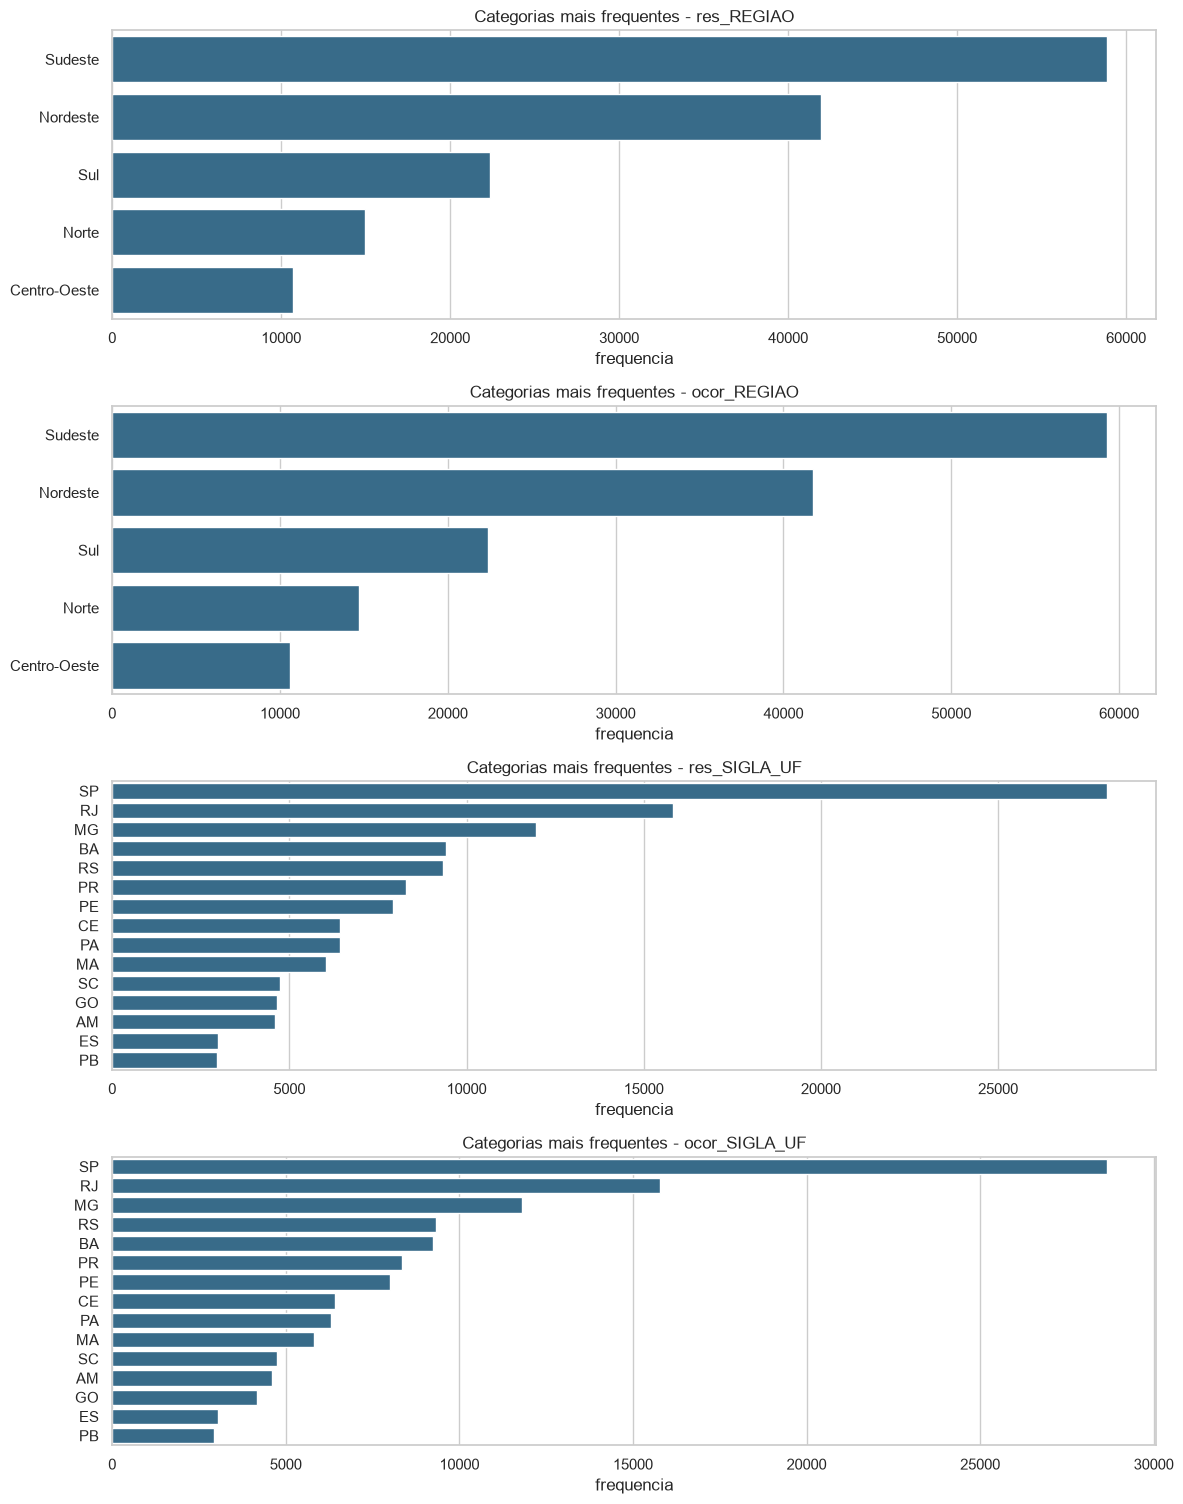

In [31]:
plot_cols = [col for col in ["res_REGIAO", "ocor_REGIAO", "res_SIGLA_UF", "ocor_SIGLA_UF"] if col in df.columns]

if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, max(4, 3.8 * len(plot_cols))))
    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, plot_cols):
        counts = df[col].value_counts(dropna=False).head(15).reset_index()
        counts.columns = [col, "frequencia"]
        sns.barplot(data=counts, y=col, x="frequencia", ax=ax, color="#2a6f97")
        ax.set_title(f"Categorias mais frequentes - {col}")
        ax.set_xlabel("frequencia")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


### Distribuicoes de todas as features por grupo

A celula abaixo percorre todas as features do dataset nos mesmos grupos definidos para o `describe`. Cada figura mostra no maximo 8 variaveis. Variaveis continuas sao exibidas como histograma; datas sao resumidas por ano; variaveis categoricas ou codigos numericos sao exibidos como barras com as categorias mais frequentes.


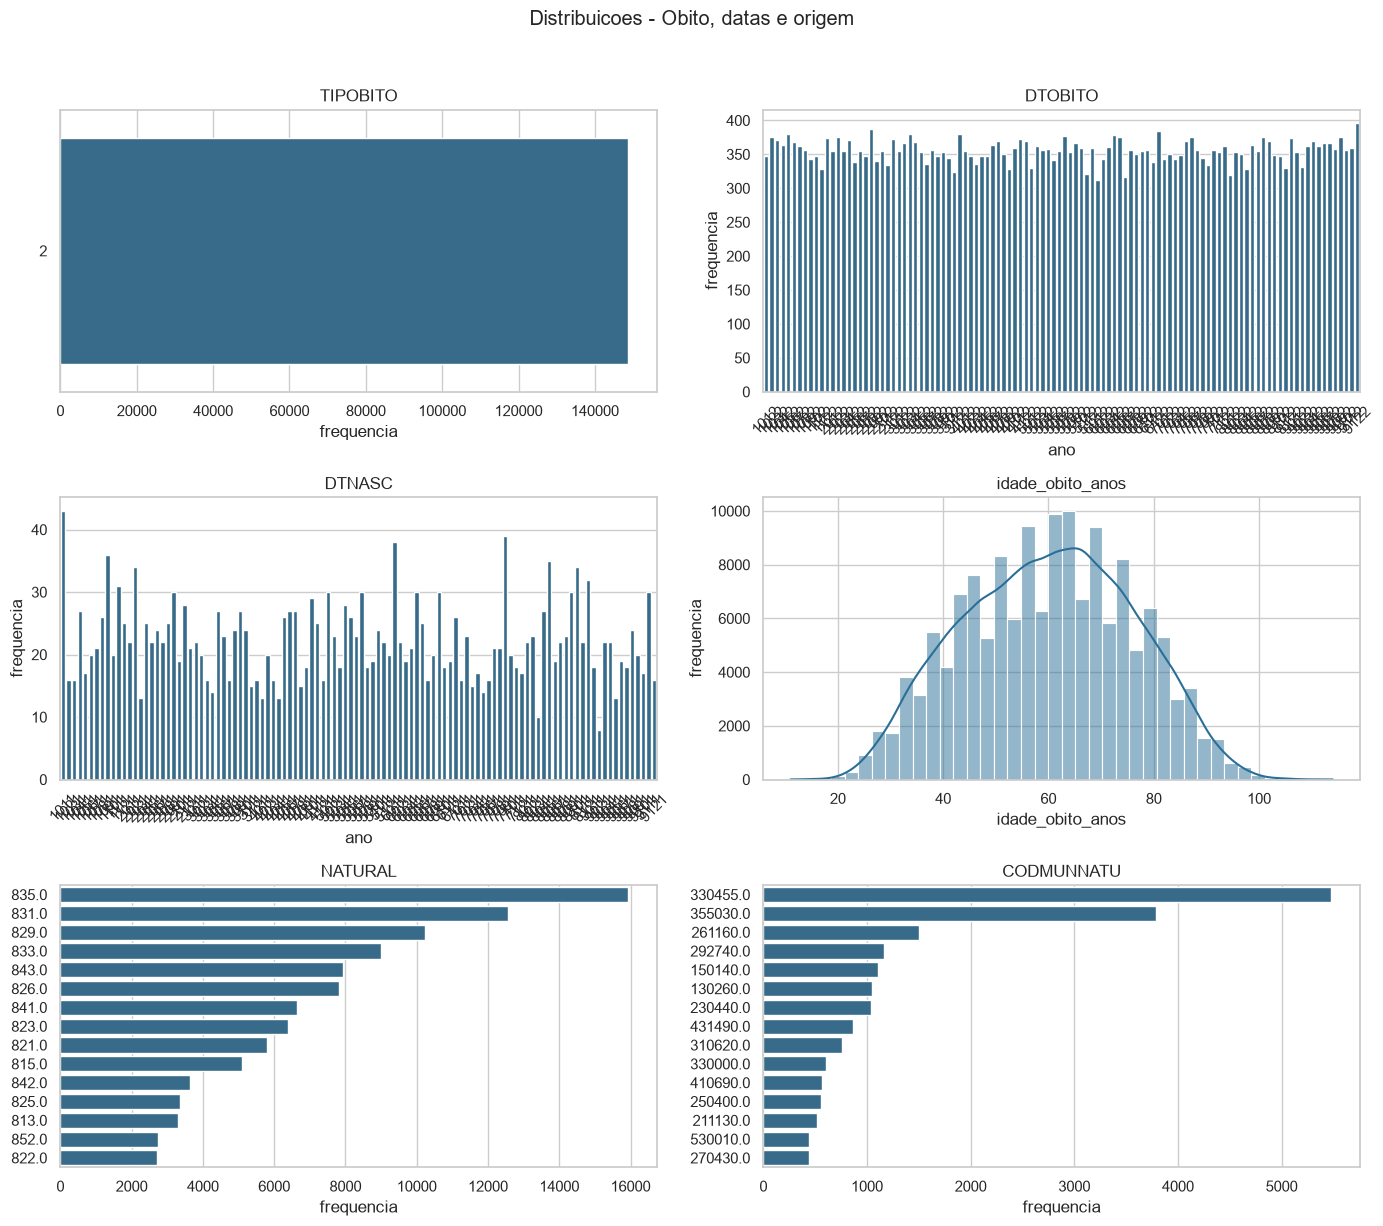

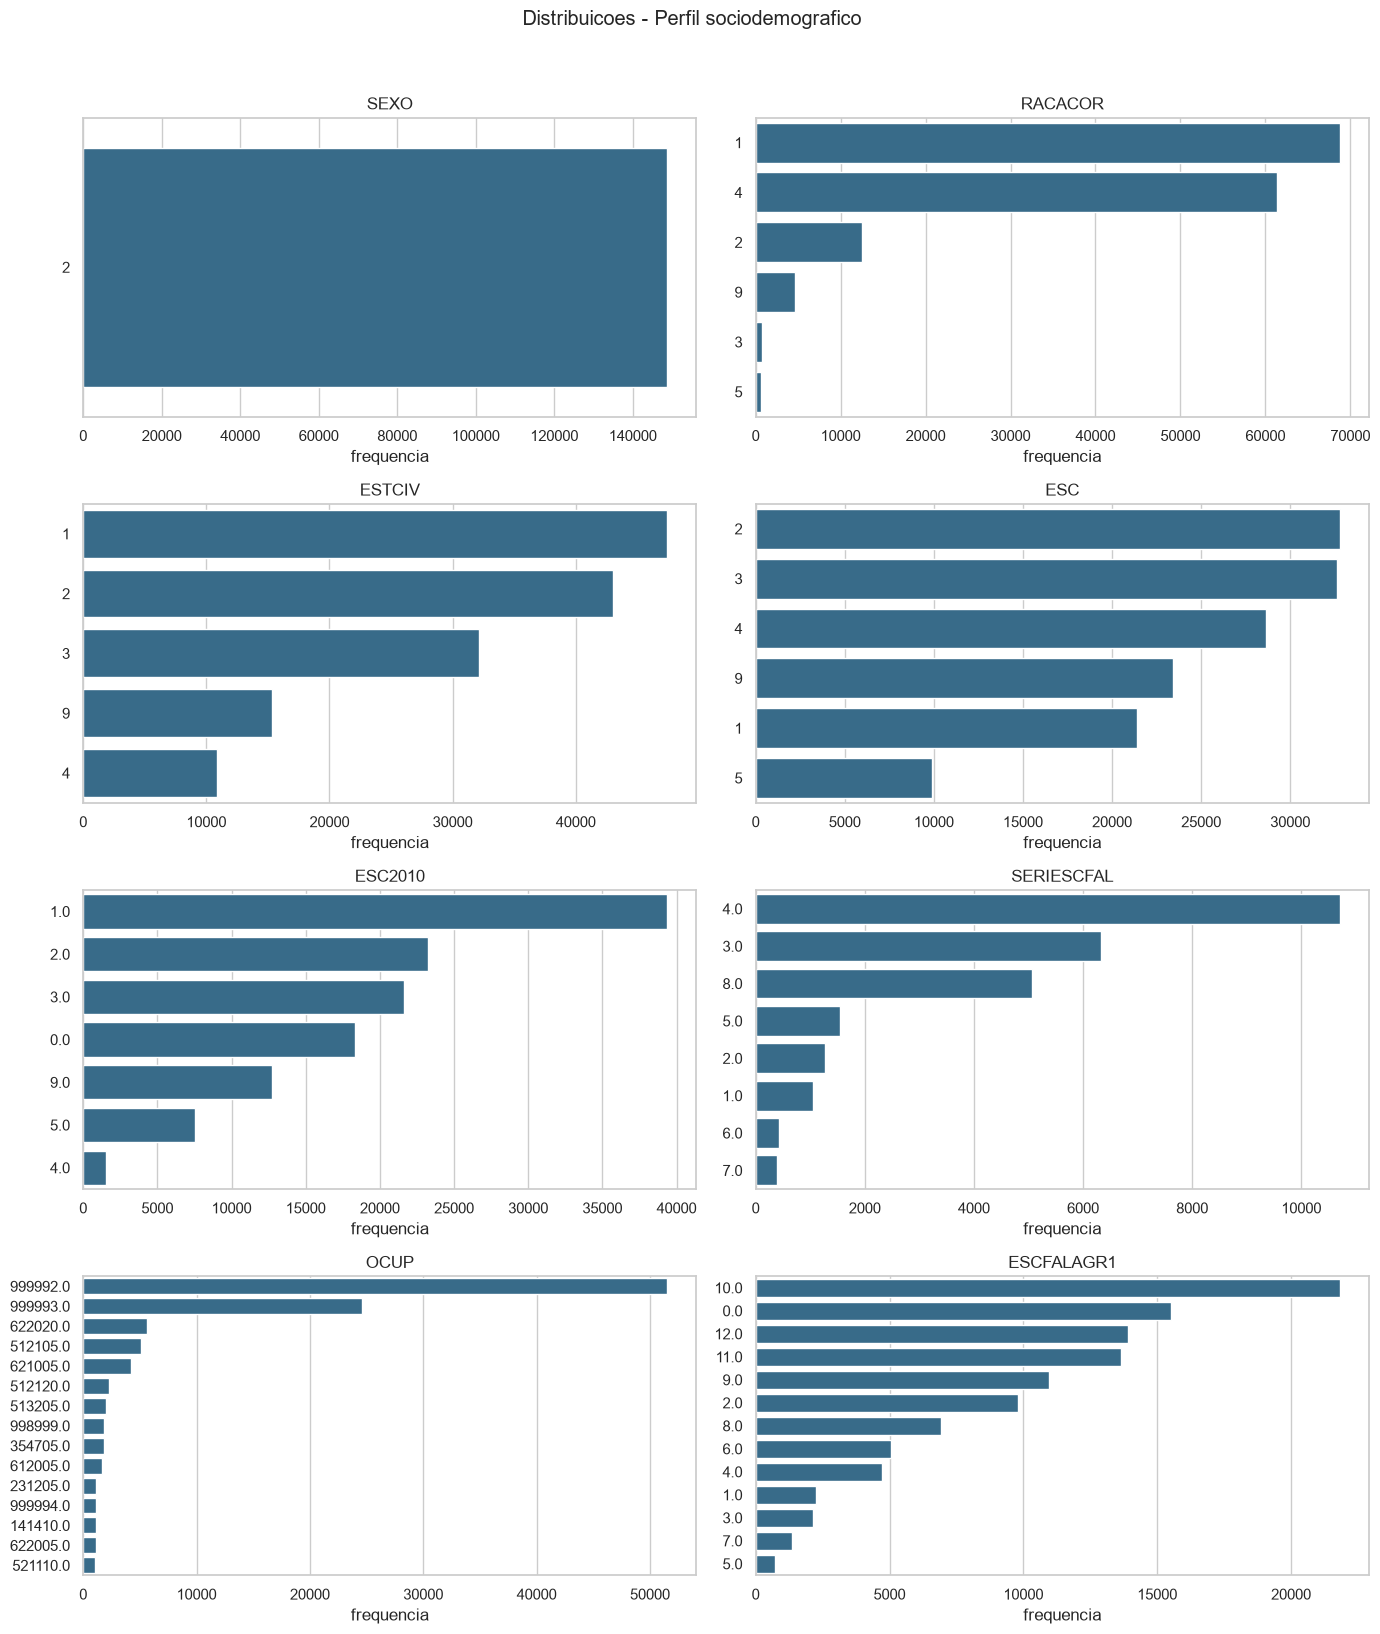

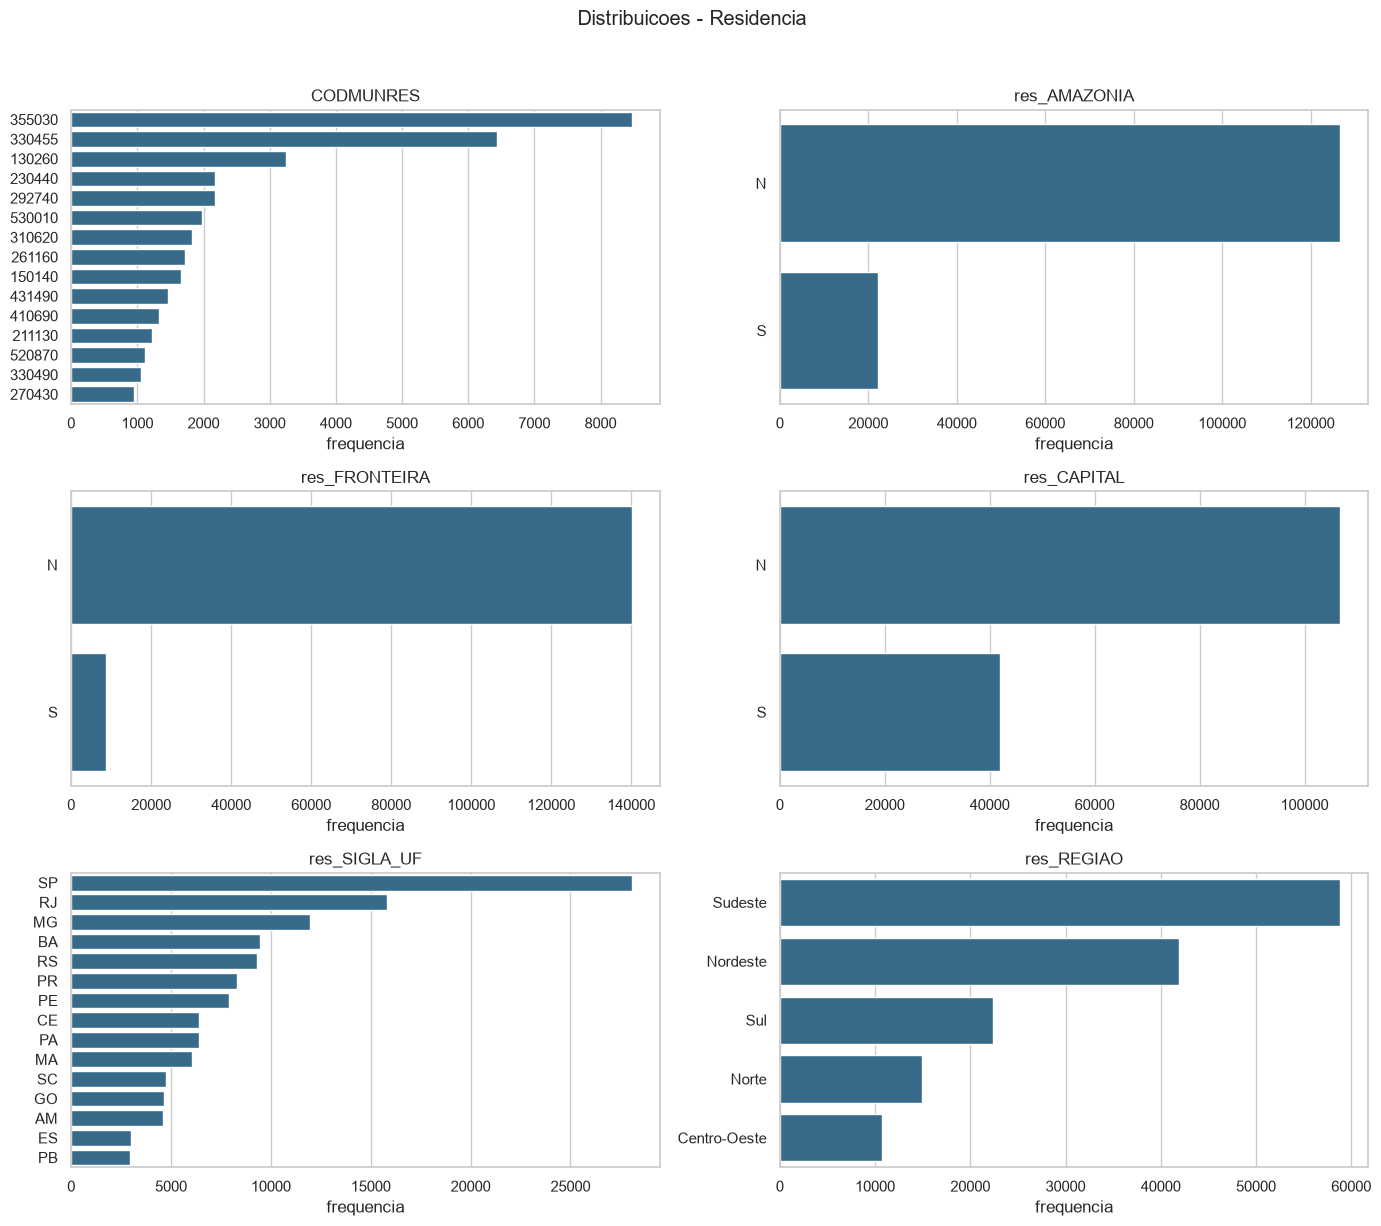

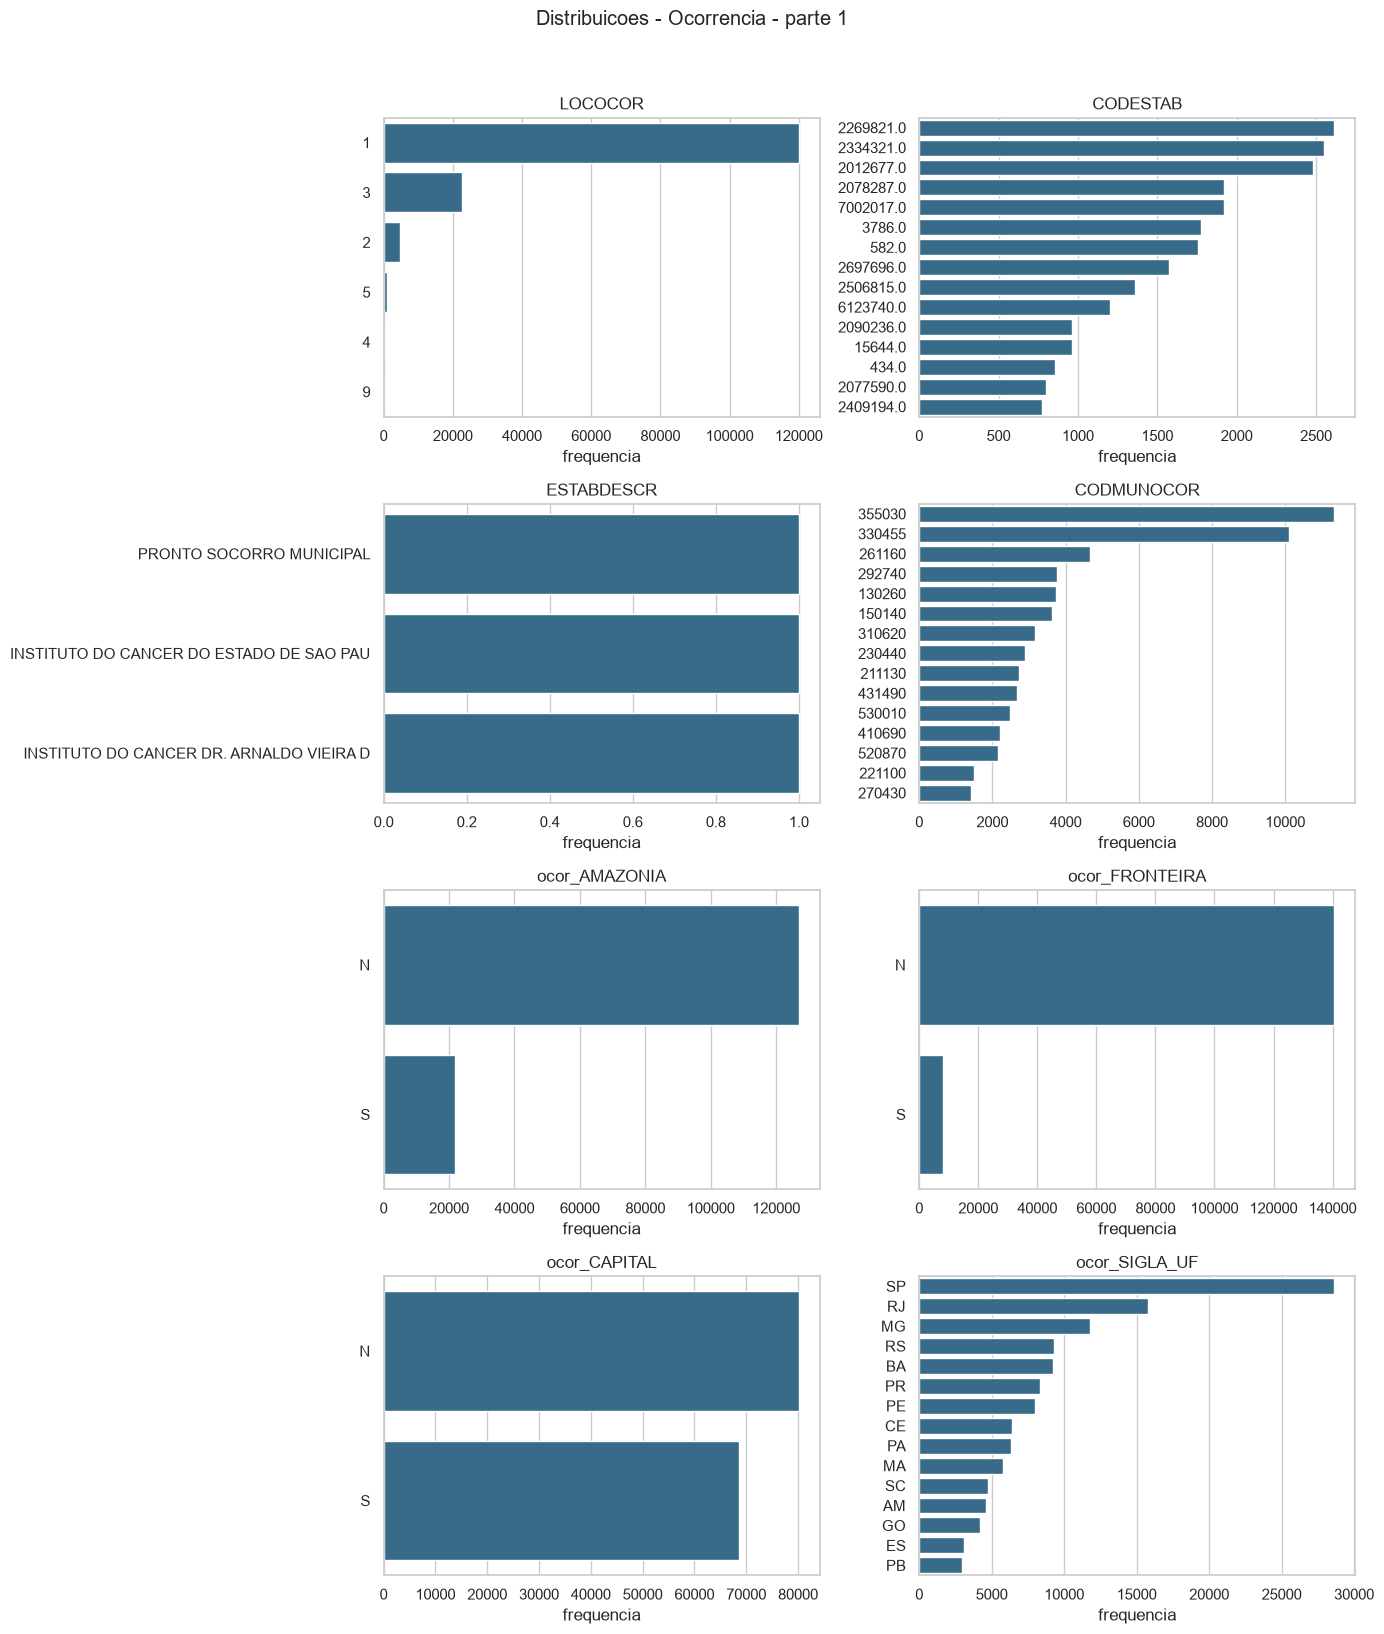

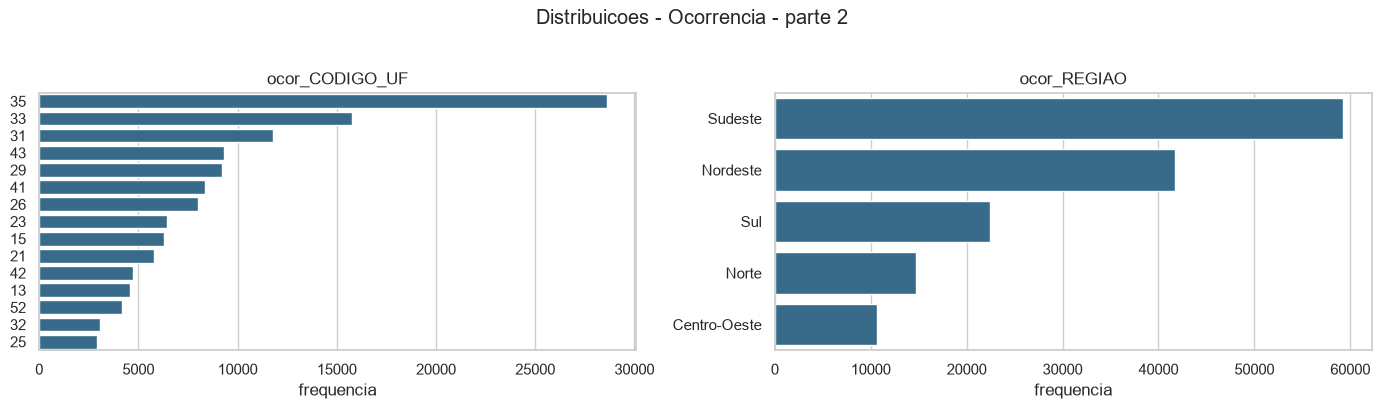

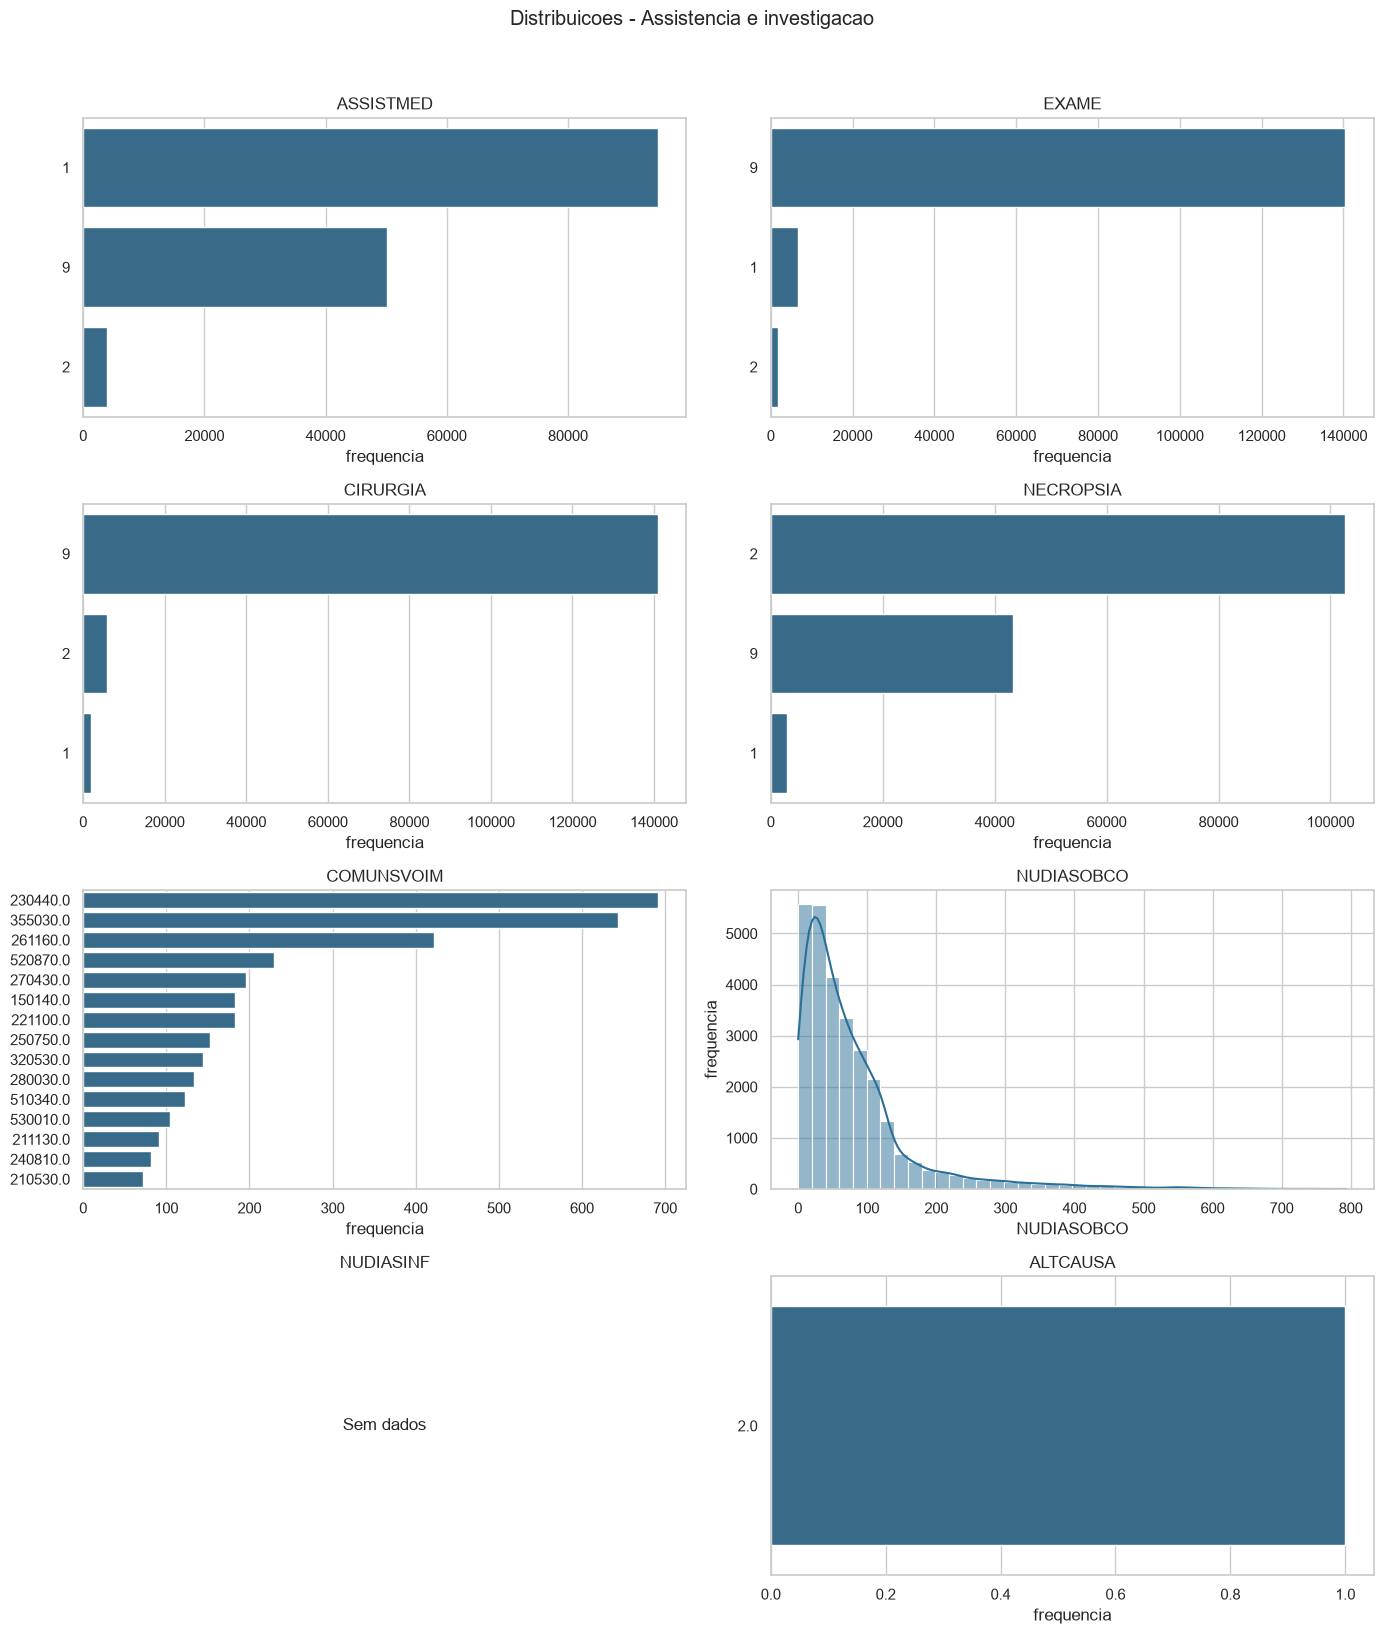

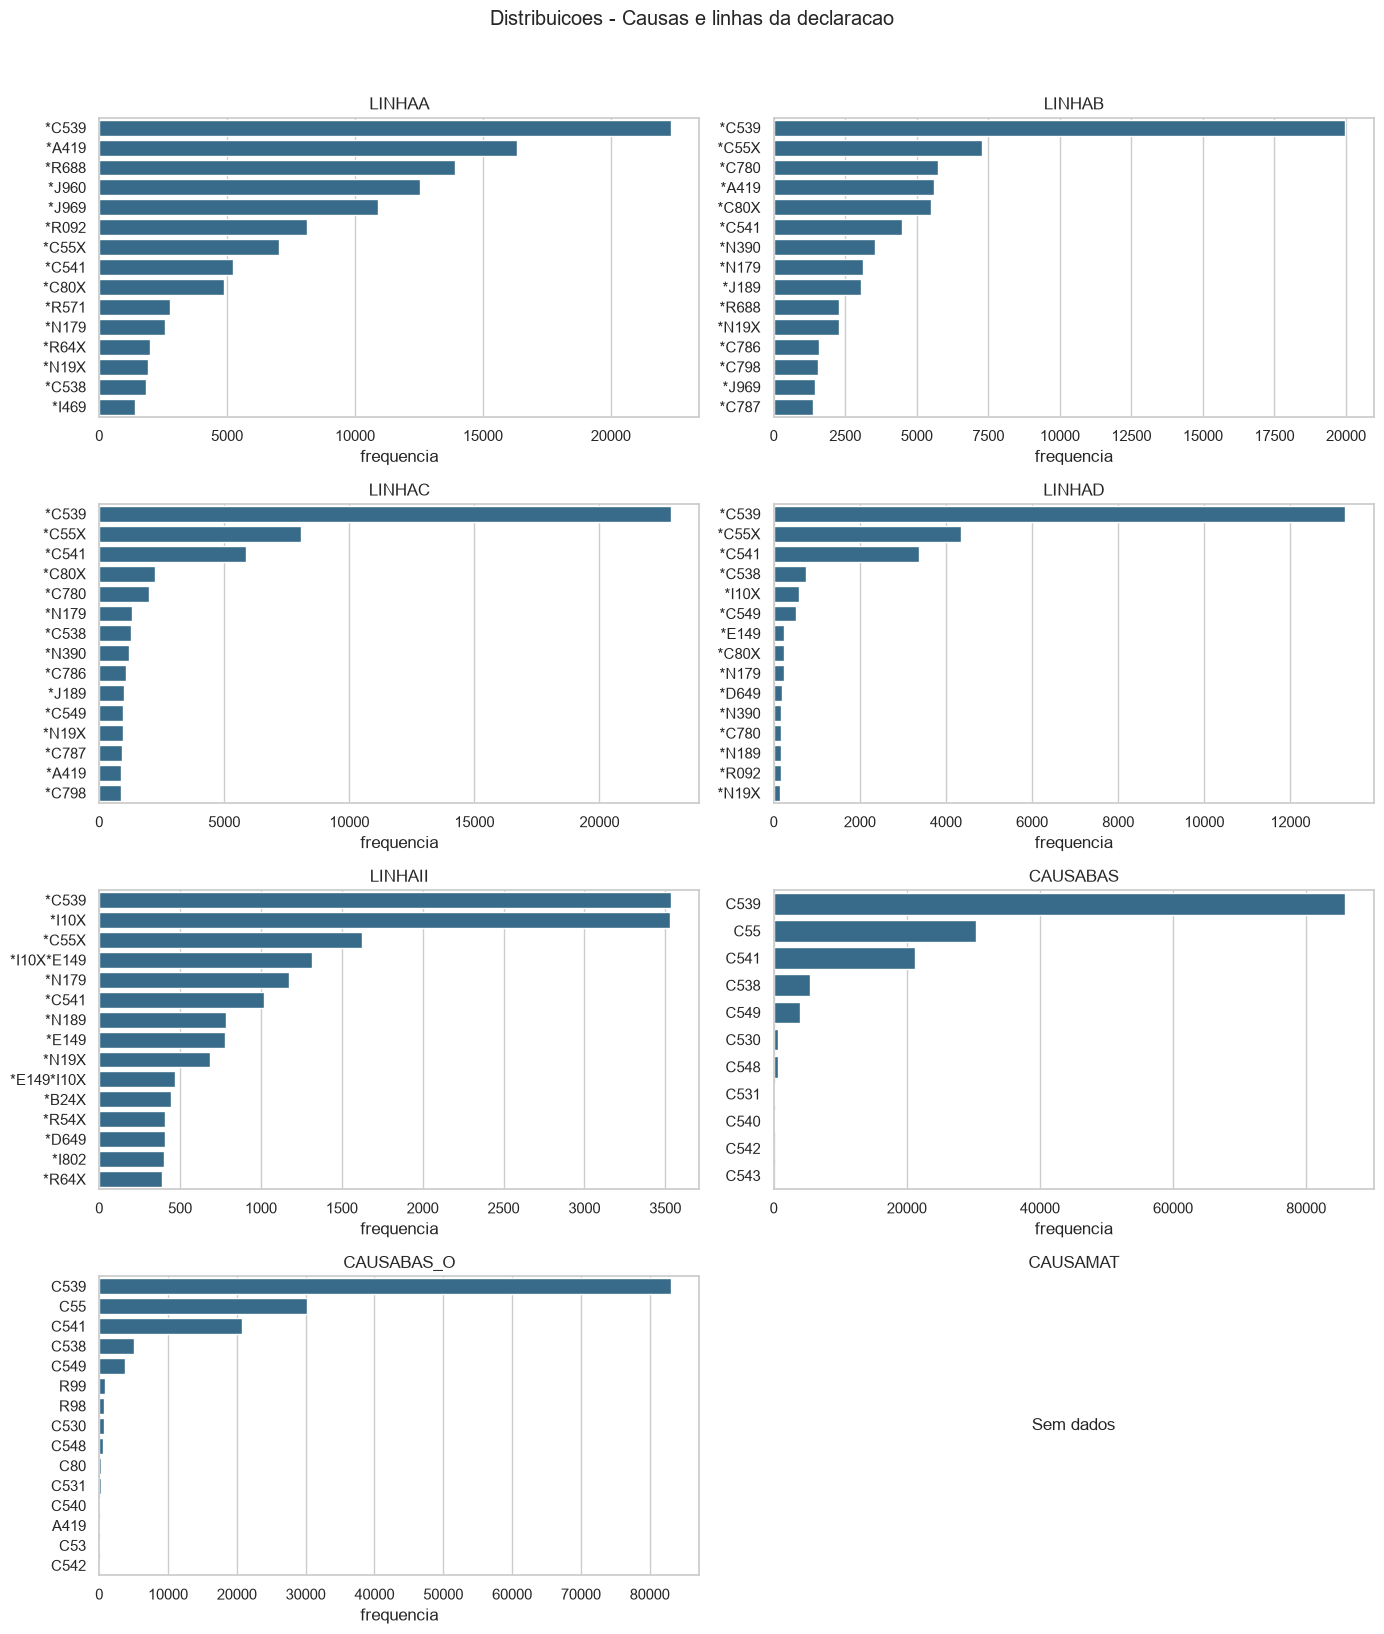

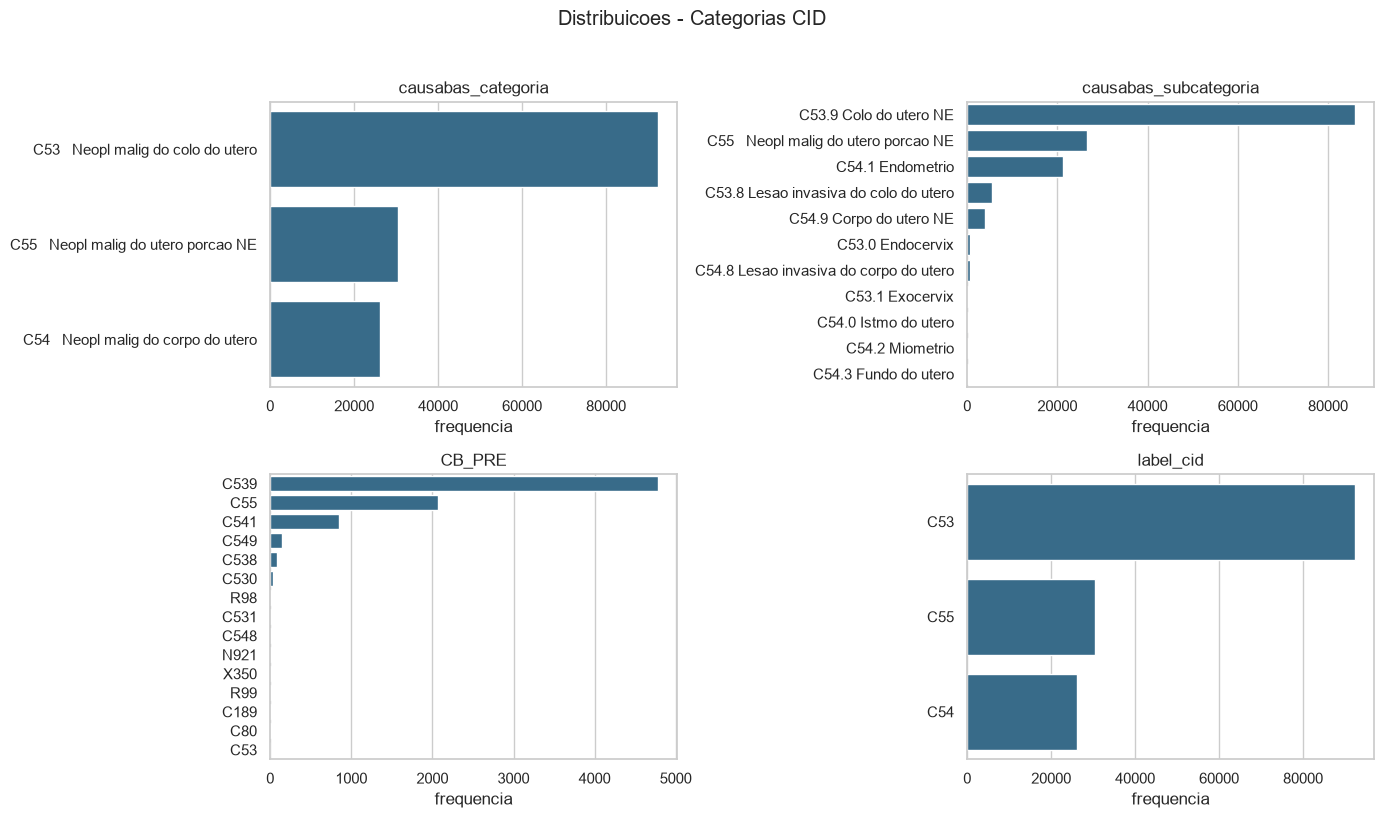

In [32]:
continuous_plot_cols = [col for col in [age_col, "NUDIASOBCO", "NUDIASINF"] if col in df.columns]
date_plot_cols = [col for col in [death_date_col, birth_date_col] if col in df.columns]
max_categories = 15
group_size = 8


def plot_single_feature_distribution(ax, data: pd.DataFrame, col: str) -> None:
    series = data[col]
    non_null = series.dropna()

    if non_null.empty:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.set_title(col)
        ax.axis("off")
        return

    if col in date_plot_cols:
        parsed = parse_yyyymmdd(series).dropna()
        if parsed.empty:
            ax.text(0.5, 0.5, "Datas invalidas", ha="center", va="center")
            ax.set_title(col)
            ax.axis("off")
            return
        year_counts = parsed.dt.year.value_counts().sort_index().reset_index()
        year_counts.columns = ["ano", "frequencia"]
        sns.barplot(data=year_counts, x="ano", y="frequencia", ax=ax, color="#2a6f97")
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("ano")
        ax.set_ylabel("frequencia")
    elif col in continuous_plot_cols:
        sns.histplot(non_null, bins=40, kde=True, ax=ax, color="#2a6f97")
        ax.set_xlabel(col)
        ax.set_ylabel("frequencia")
    else:
        counts = non_null.astype("string").value_counts().head(max_categories).reset_index()
        counts.columns = [col, "frequencia"]
        sns.barplot(data=counts, y=col, x="frequencia", ax=ax, color="#2a6f97")
        ax.set_xlabel("frequencia")
        ax.set_ylabel("")

    ax.set_title(col)


def plot_feature_group_distributions(group_name: str, cols: list[str]) -> None:
    available_cols = [col for col in cols if col in df.columns]

    for start in range(0, len(available_cols), group_size):
        block_cols = available_cols[start:start + group_size]
        n_cols = 2
        n_rows_plot = int(np.ceil(len(block_cols) / n_cols))
        fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(14, 4 * n_rows_plot))
        axes = np.atleast_1d(axes).flatten()

        for ax, col in zip(axes, block_cols):
            plot_single_feature_distribution(ax, df, col)

        for ax in axes[len(block_cols):]:
            ax.axis("off")

        suffix = f" - parte {start // group_size + 1}" if len(available_cols) > group_size else ""
        fig.suptitle(f"Distribuicoes - {group_name}{suffix}", y=1.02)
        plt.tight_layout()
        plt.show()


all_grouped_cols = []
for group_name, group_cols in feature_groups.items():
    all_grouped_cols.extend([col for col in group_cols if col in df.columns])
    plot_feature_group_distributions(group_name, group_cols)

remaining_plot_cols = [col for col in df.columns if col not in all_grouped_cols]
plot_feature_group_distributions("Outras features", remaining_plot_cols)


### Leitura das estatisticas gerais

Nesta base, e importante nao tratar toda coluna numerica como medida continua. Muitas variaveis sao codigos administrativos, como sexo, raca/cor, escolaridade, local de ocorrencia e municipio. Para modelagem com rede neural, isso sugere um pre-processamento com separacao clara entre:

- variaveis continuas, como `idade_obito_anos`;
- variaveis categoricas codificadas por numero;
- variaveis textuais de causa e localizacao;
- colunas com muitos nulos ou cardinalidade muito alta, que podem exigir selecao, agrupamento ou descarte.


## 4. Analise do alvo `label_cid`

Nesta secao exploramos o alvo inicial do problema. A coluna `label_cid` indica a categoria CID associada ao registro, e pode ser usada como alvo em uma tarefa de classificacao. O objetivo aqui e verificar desbalanceamento entre classes e observar relacoes iniciais com idade e localizacao.


### Distribuicao das classes


In [33]:
target_summary = df[target_col].value_counts(dropna=False).rename_axis(target_col).reset_index(name="frequencia")
target_summary["percent"] = 100 * target_summary["frequencia"] / n_rows
target_summary["percent_acumulado"] = target_summary["percent"].cumsum()

display(target_summary.style.format({
    "frequencia": "{:,}",
    "percent": "{:.2f}%",
    "percent_acumulado": "{:.2f}%",
}))


,label_cid,frequencia,percent,percent_acumulado
0,C53,"92,287",62.03%,62.03%
1,C55,"30,345",20.40%,82.42%
2,C54,"26,153",17.58%,100.00%


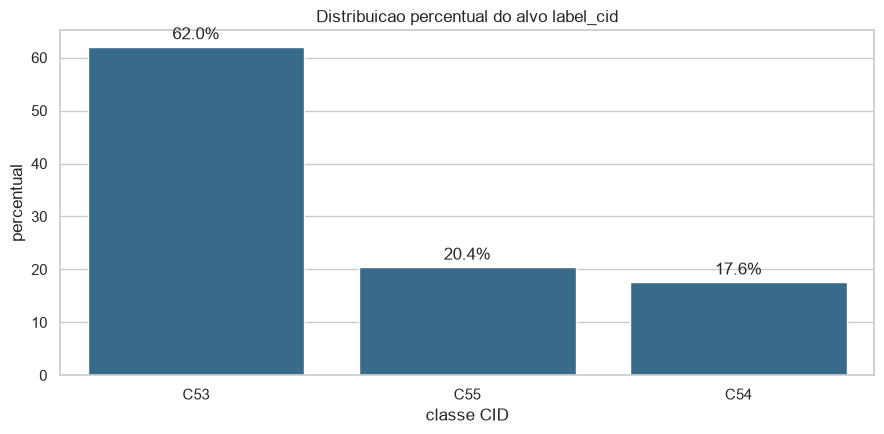

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.barplot(data=target_summary, x=target_col, y="percent", ax=ax, color="#2a6f97")
ax.set_title("Distribuicao percentual do alvo label_cid")
ax.set_xlabel("classe CID")
ax.set_ylabel("percentual")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


### Idade por classe do alvo

A distribuicao da idade por classe ajuda a verificar se alguma categoria CID aparece mais associada a faixas etarias especificas. Isso e relevante porque `idade_obito_anos` tende a ser uma variavel preditiva forte em bases de mortalidade.


,count,mean,std,min,10%,25%,50%,75%,90%,max
label_cid,,,,,,,,,,
C53,"92,283.0000",56.7087,16.0465,13.0000,36.0000,44.0000,56.0000,68.0000,79.0000,113.0000
C54,"26,152.0000",67.7557,12.2706,13.0000,52.0000,60.0000,68.0000,76.0000,83.0000,114.0000
C55,"30,339.0000",63.3389,15.7089,11.0000,42.0000,52.0000,64.0000,75.0000,84.0000,111.0000


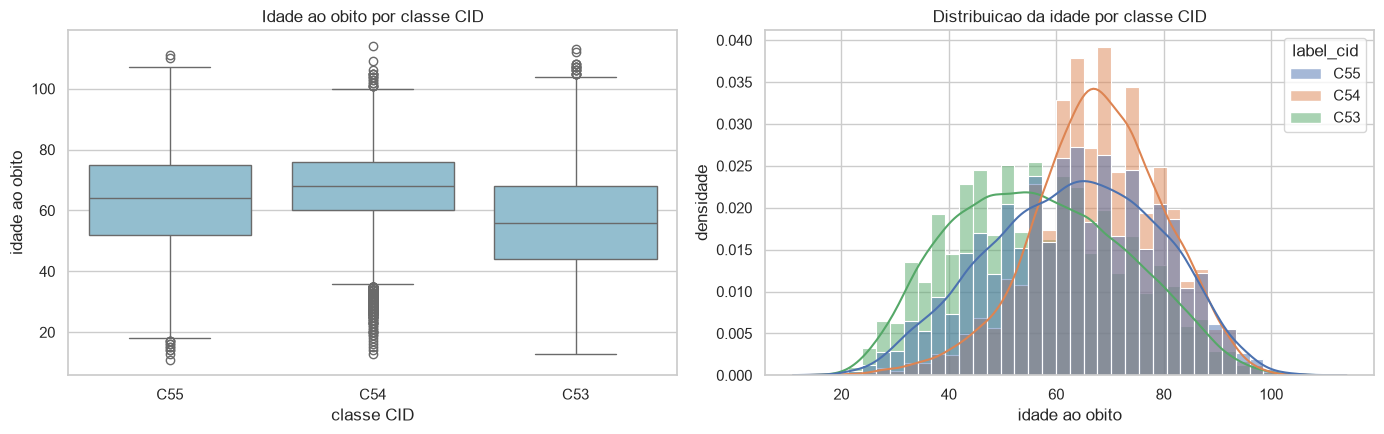

In [35]:
if age_col in df.columns:
    age_by_target = (
        df.groupby(target_col)[age_col]
        .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        .sort_index()
    )
    display(age_by_target)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    sns.boxplot(data=df, x=target_col, y=age_col, ax=axes[0], color="#89c2d9")
    axes[0].set_title("Idade ao obito por classe CID")
    axes[0].set_xlabel("classe CID")
    axes[0].set_ylabel("idade ao obito")

    sns.histplot(data=df, x=age_col, hue=target_col, bins=40, kde=True, stat="density", common_norm=False, ax=axes[1])
    axes[1].set_title("Distribuicao da idade por classe CID")
    axes[1].set_xlabel("idade ao obito")
    axes[1].set_ylabel("densidade")

    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame({"mensagem": ["Coluna de idade nao encontrada."]}))


### Alvo por regiao e UF

As tabelas abaixo mostram a composicao percentual do alvo dentro das principais variaveis de localizacao. Isso ajuda a identificar diferencas regionais e possiveis efeitos de distribuicao da base.


In [36]:
location_cols = [col for col in ["res_REGIAO", "ocor_REGIAO", "res_SIGLA_UF", "ocor_SIGLA_UF"] if col in df.columns]

for col in location_cols:
    display_section(f"Distribuicao percentual de {target_col} por {col}")
    table = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    counts = df[col].value_counts(dropna=False).rename("total_registros")
    table = table.join(counts)
    display(table.sort_values("total_registros", ascending=False).head(20).style.format("{:.2f}"))


### Distribuicao percentual de label_cid por res_REGIAO

,C53,C54,C55,total_registros
res_REGIAO,,,,
Sudeste,51.89,23.63,24.49,58847.00
Nordeste,68.84,12.86,18.30,41922.00
Sul,60.11,18.49,21.40,22352.00
Norte,81.58,7.03,11.39,14940.00
Centro-Oeste,67.79,15.62,16.59,10724.00


### Distribuicao percentual de label_cid por ocor_REGIAO

,C53,C54,C55,total_registros
ocor_REGIAO,,,,
Sudeste,52.03,23.57,24.39,59254.00
Nordeste,68.81,12.87,18.32,41770.00
Sul,60.11,18.52,21.37,22412.00
Norte,81.67,6.95,11.38,14731.00
Centro-Oeste,67.88,15.40,16.72,10618.00


### Distribuicao percentual de label_cid por res_SIGLA_UF

,C53,C54,C55,total_registros
res_SIGLA_UF,,,,
SP,49.65,26.23,24.12,28062.00
RJ,51.98,22.85,25.17,15819.00
MG,53.64,20.56,25.80,11970.00
BA,65.12,13.17,21.71,9433.00
RS,58.32,19.20,22.48,9328.00
PR,60.60,18.41,20.98,8298.00
PE,61.75,18.96,19.30,7924.00
PA,78.36,6.99,14.65,6422.00
CE,69.40,13.75,16.85,6422.00


### Distribuicao percentual de label_cid por ocor_SIGLA_UF

,C53,C54,C55,total_registros
ocor_SIGLA_UF,,,,
SP,50.06,26.08,23.86,28643.00
RJ,52.01,22.81,25.17,15766.00
MG,53.38,20.60,26.02,11790.00
RS,58.31,19.20,22.49,9326.00
BA,64.95,13.13,21.92,9233.00
PR,60.61,18.46,20.93,8352.00
PE,61.87,18.98,19.15,8004.00
CE,69.36,13.76,16.87,6430.00
PA,78.37,6.85,14.78,6306.00


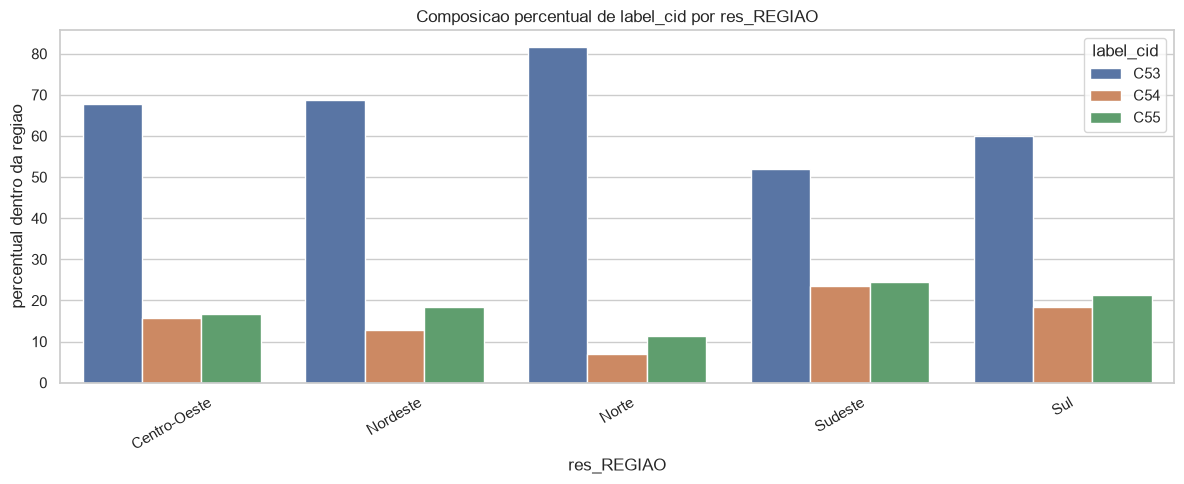

In [37]:
region_col = "res_REGIAO" if "res_REGIAO" in df.columns else ("ocor_REGIAO" if "ocor_REGIAO" in df.columns else None)

if region_col is not None:
    region_target = (
        pd.crosstab(df[region_col], df[target_col], normalize="index")
        .mul(100)
        .reset_index()
        .melt(id_vars=region_col, var_name=target_col, value_name="percent")
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=region_target, x=region_col, y="percent", hue=target_col, ax=ax)
    ax.set_title(f"Composicao percentual de {target_col} por {region_col}")
    ax.set_xlabel(region_col)
    ax.set_ylabel("percentual dentro da regiao")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


### Leitura inicial do alvo

Depois de executar esta secao, observe se uma classe domina muito a distribuicao de `label_cid`. Caso exista desbalanceamento, a etapa de modelagem deve considerar metricas alem de acuracia, como `f1_macro`, matriz de confusao e desempenho por classe.

Tambem vale observar se idade, regiao ou UF parecem mudar a composicao das classes. Essas diferencas nao provam causalidade, mas indicam variaveis que podem ser relevantes para o algoritmo genetico selecionar ou para o pre-processamento tratar com mais cuidado.
